In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns



In [954]:
df=pd.read_csv("utils/cleaned_dataset.csv")
df.shape

(16113, 25)

In [955]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16113 entries, 0 to 16112
Data columns (total 25 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   house_index       16113 non-null  int64  
 1   bedrooms          16113 non-null  int64  
 2   property_type     16113 non-null  object 
 3   property_subtype  16113 non-null  object 
 4   locality          16113 non-null  object 
 5   postal_code       16113 non-null  object 
 6   street            15698 non-null  object 
 7   number            15597 non-null  object 
 8   box               5027 non-null   object 
 9   kitchen           16113 non-null  int64  
 10  facades           11578 non-null  float64
 11  price             16112 non-null  float64
 12  furnished         16113 non-null  int64  
 13  terrace           16113 non-null  int64  
 14  terraceSurface    11340 non-null  float64
 15  fireplace         16113 non-null  int64  
 16  fireplaceCount    16113 non-null  int64 

In [956]:
#convert the non-numerical column to numeric
#df = df.apply(pd.to_numeric, errors='coerce')

#remove NaN values 
df.dropna(how='all', inplace=True)

#1.No duplicates
df.drop_duplicates(subset=['postal_code','street','number','box'], inplace=True)

#2.No blank spaces 
# remove leading/ trailing spaces on the entire dataframe
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

#remove leading/ trailing spaces on specific string column in the dataframe
#df['street']=df['street'].str.strip()

#remove the property with no price because there is one property.
df = df.dropna(subset=['price'])

#remove the landsurface bcoz it is duplicated with surfaceof plot
df.drop(columns='landSurface',inplace=True)
#df['price'] = df['price'].fillna(df['price'].mean())
#print(df.shape)
df = df[df['facades'] < 9]
df =df[df['bedrooms'] < 10]
df.shape




(11536, 24)

In [957]:
df = df[df['house_index'] != 19838]
df = df[df['house_index'] != 19839]
df = df[df['house_index'] != 5356]
df.shape

(11533, 24)

In [958]:
missing_percentage = (df.isna().sum() / len(df)) * 100
print(missing_percentage)

house_index          0.000000
bedrooms             0.000000
property_type        0.000000
property_subtype     0.000000
locality             0.000000
postal_code          0.000000
street               3.182173
number               3.997225
box                 76.797017
kitchen              0.000000
facades              0.000000
price                0.000000
furnished            0.000000
terrace              0.000000
terraceSurface      29.610682
fireplace            0.000000
fireplaceCount       0.000000
buildingState       15.754791
garden               0.000000
gardenSurface        0.000000
pool                 0.000000
livingArea           4.604179
surfaceOfThePlot    35.177317
typeOfSale          74.672678
dtype: float64


In [959]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_without_outliers = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
    print(f'{len(df)-len(df_without_outliers)} rows have been removed from the {column} column')
    return df_without_outliers


#handling the outliers
df_without_outliers=remove_outliers(df, 'price')
#df_without_outliers=remove_outliers(df_without_outliers, 'surfaceOfThePlot')
df_without_outliers=remove_outliers(df_without_outliers, 'livingArea')

840 rows have been removed from the price column
905 rows have been removed from the livingArea column


In [960]:
df_without_outliers.shape

(9788, 24)

In [1013]:
df=df_without_outliers
df.shape

(9788, 25)

In [1014]:
#correlation btw price and other variables(Top 5) on df without outliers
df_numeric = df.select_dtypes(include=['number'])

high_correlation = df_numeric.corr()['price'].sort_values(ascending=False).head(5)
print(high_correlation)



price               1.000000
livingArea          0.569014
bedrooms            0.437755
facades             0.268619
surfaceOfThePlot    0.226504
Name: price, dtype: float64


In [963]:

low_correlation = df_numeric.corr()['price'].sort_values(ascending=True).head(5)
print(low_correlation)

furnished        -0.001179
fireplaceCount    0.007787
kitchen           0.017353
terraceSurface    0.058232
gardenSurface     0.067592
Name: price, dtype: float64


In [1015]:
columns_to_exclude = ['house_index', 'property_type','property_subtype','locality','street','buildingState','typeOfSale','box','number']
filtered_df = df.drop(columns=columns_to_exclude)

# Calculate correlation matrix
correlation_matrix = filtered_df.select_dtypes(include=['number']).corr()

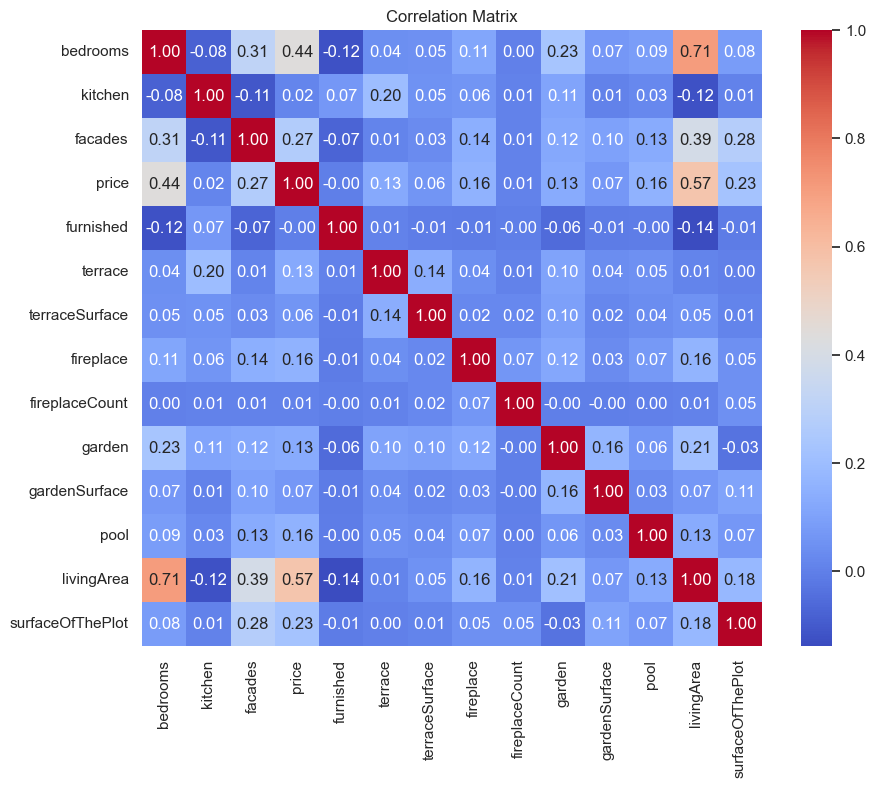

In [1016]:
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

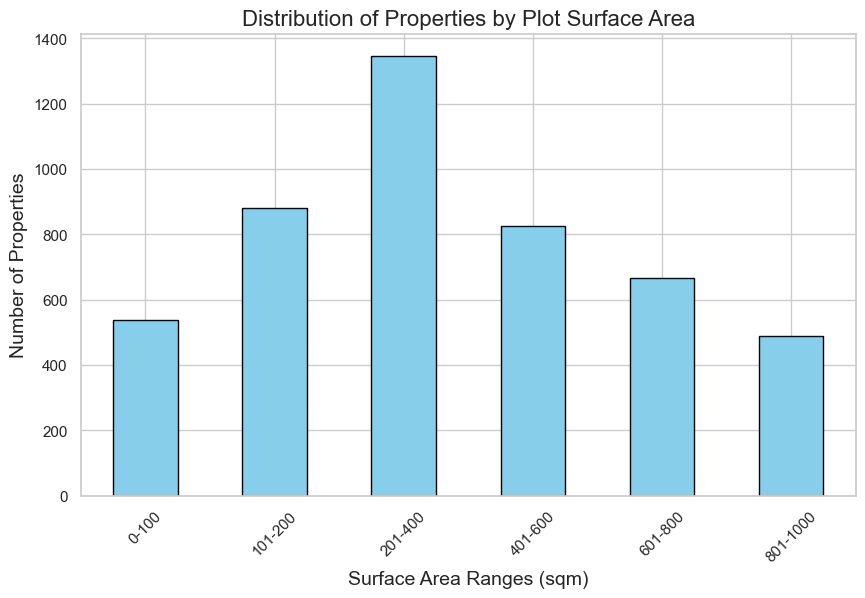

In [1017]:
bins = [0, 100, 200, 400, 600, 800, 1000]  # Define bin edges
bin_labels = ['0-100', '101-200', '201-400', '401-600', '601-800', '801-1000']

# Step 2: Create a new column for the binned data
df['SurfaceBins'] = pd.cut(df['surfaceOfThePlot'], bins=bins, labels=bin_labels, include_lowest=True)

# Step 3: Plot a histogram based on the binned data
plt.figure(figsize=(10, 6))
df['SurfaceBins'].value_counts(sort=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Properties by Plot Surface Area', fontsize=16)
plt.xlabel('Surface Area Ranges (sqm)', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)
plt.xticks(rotation=45)
plt.show()

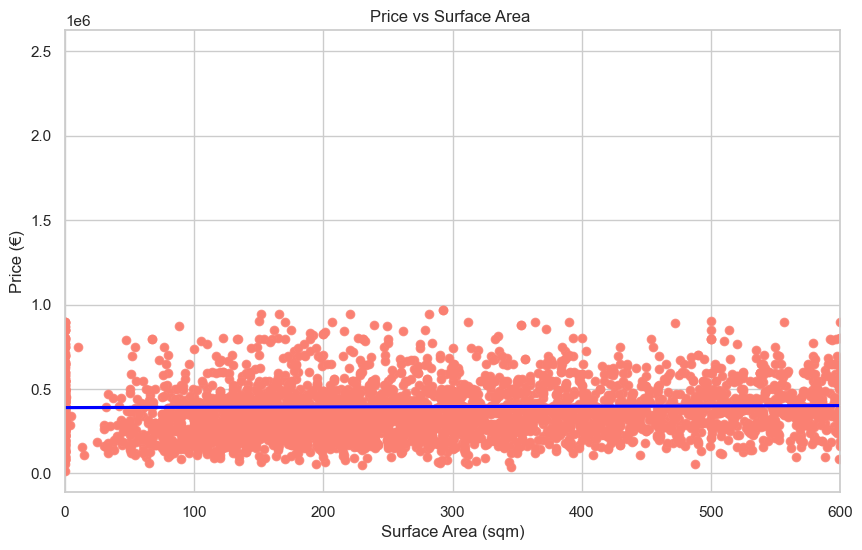

In [1018]:

plt.figure(figsize=(10, 6))
sns.scatterplot(x='surfaceOfThePlot', y='price', data=df, color='salmon')
sns.regplot(x='surfaceOfThePlot', y='price', data=df, scatter_kws={'color': 'salmon'}, line_kws={'color': 'blue'})
# Add title and labels
plt.title('Price vs Surface Area ')
plt.xlabel('Surface Area (sqm)')
plt.ylabel('Price (€)')
plt.xlim(0, 600)
plt.show()

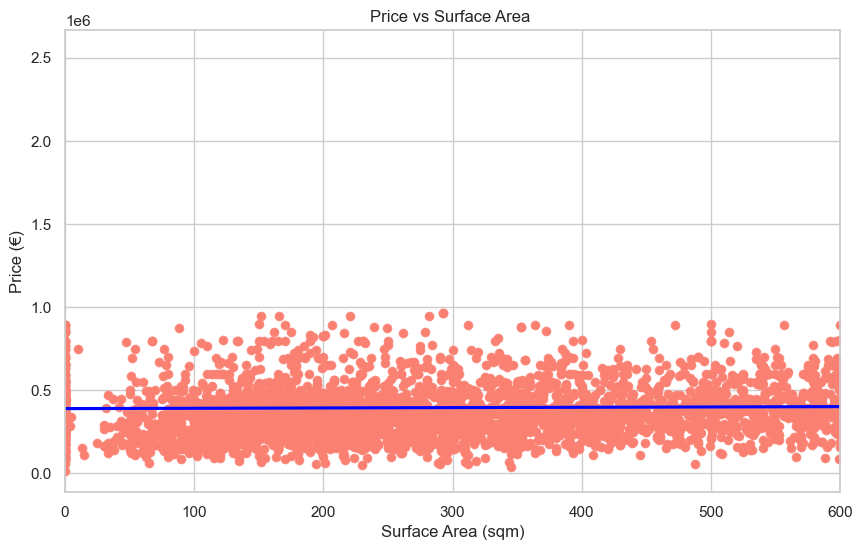

In [1019]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='surfaceOfThePlot', y='price', data=df, color='salmon')
sns.regplot(x='surfaceOfThePlot', y='price', data=df, scatter_kws={'color': 'salmon'}, line_kws={'color': 'blue'})
# Add title and labels
plt.title('Price vs Surface Area ')
plt.xlabel('Surface Area (sqm)')
plt.ylabel('Price (€)')
plt.xlim(0, 600)
plt.show()

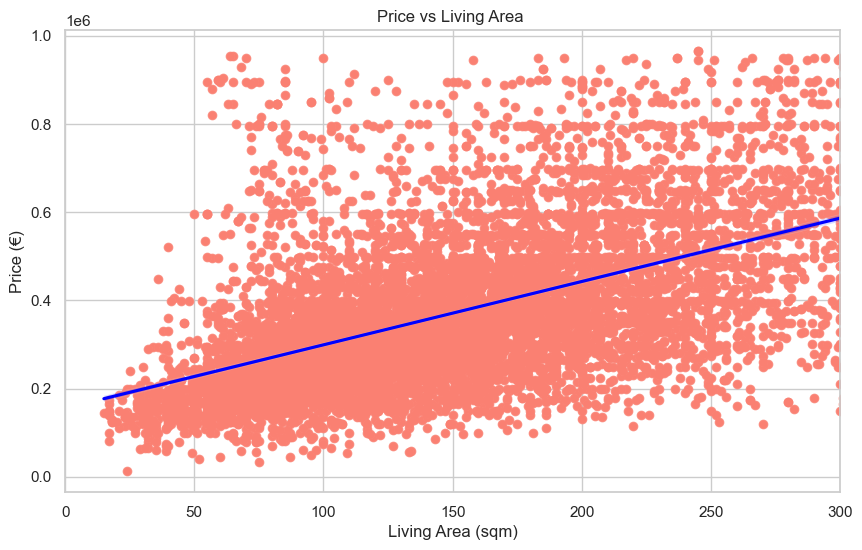

In [1020]:

#df['log_livingArea'] = np.log1p(df['livingArea'])  # log(1 + livingArea)
#df['log_price'] = np.log1p(df['price'])

plt.figure(figsize=(10, 6))
sns.scatterplot(x='livingArea', y='price', data=df, color='salmon')
sns.regplot(x='livingArea', y='price', data=df, scatter_kws={'color': 'salmon'}, line_kws={'color': 'blue'})
# Add title and labels
plt.title('Price vs Living Area ')
plt.xlabel('Living Area (sqm)')
plt.ylabel('Price (€)')
plt.xlim(0, 300)
#plt.ylim(0, 0.6)


plt.show()

In [1021]:
df['price_per_sqmt']= df['price']/df['livingArea']
df['price_per_sqmt'] = df['price_per_sqmt'].where(df['livingArea'].notna())
df.columns

Index(['house_index', 'bedrooms', 'property_type', 'property_subtype',
       'locality', 'postal_code', 'street', 'number', 'box', 'kitchen',
       'facades', 'price', 'furnished', 'terrace', 'terraceSurface',
       'fireplace', 'fireplaceCount', 'buildingState', 'garden',
       'gardenSurface', 'pool', 'livingArea', 'surfaceOfThePlot', 'typeOfSale',
       'SurfaceBins', 'price_per_sqmt'],
      dtype='object')

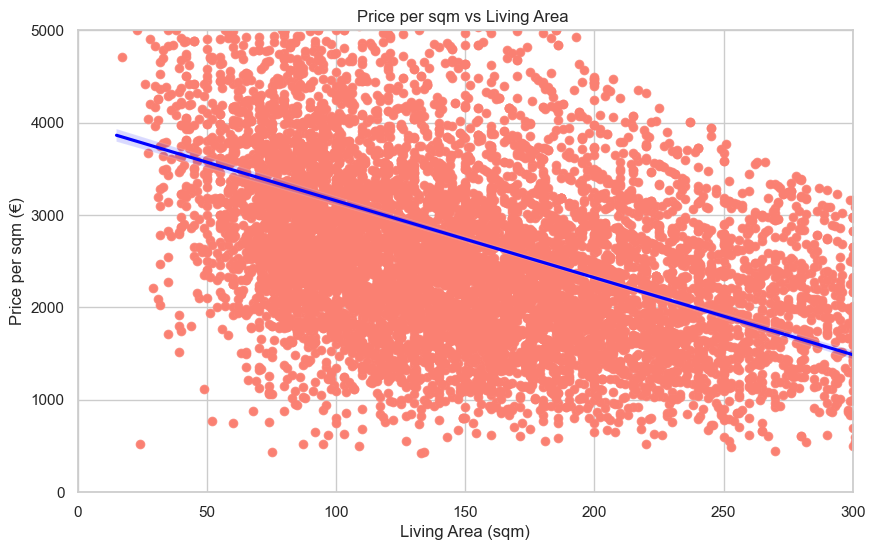

In [1022]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='livingArea', y='price_per_sqmt', data=df, color='salmon')
sns.regplot(x='livingArea', y='price_per_sqmt', data=df, scatter_kws={'color': 'salmon'}, line_kws={'color': 'blue'})
# Add title and labels
plt.title('Price per sqm vs Living Area ')
plt.xlabel('Living Area (sqm)')
plt.ylabel('Price per sqm (€)')
plt.xlim(0, 300)
plt.ylim(0, 5000)


plt.show()

(0.0, 5000.0)

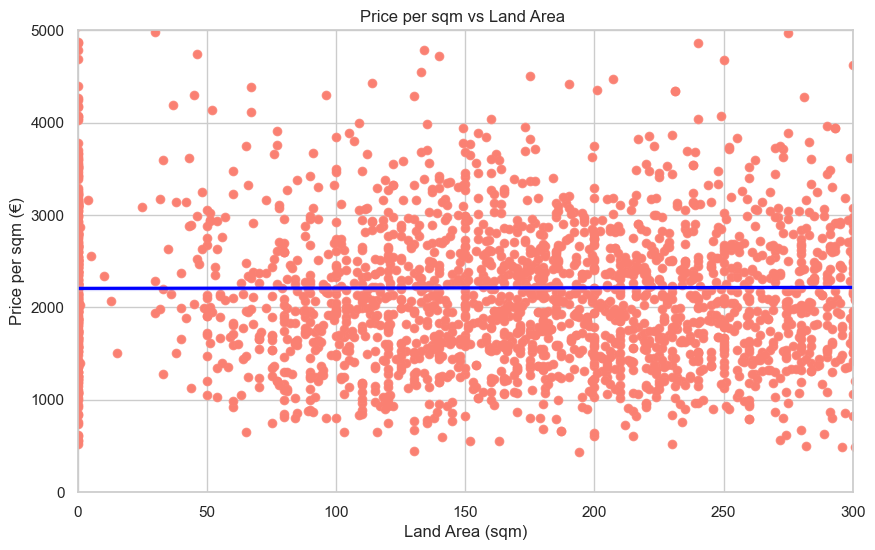

In [1023]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='surfaceOfThePlot', y='price_per_sqmt', data=df, color='salmon')
sns.regplot(x='surfaceOfThePlot', y='price_per_sqmt', data=df, scatter_kws={'color': 'salmon'}, line_kws={'color': 'blue'})
# Add title and labels
plt.title('Price per sqm vs Land Area ')
plt.xlabel('Land Area (sqm)')
plt.ylabel('Price per sqm (€)')
plt.xlim(0, 300)
plt.ylim(0, 5000)

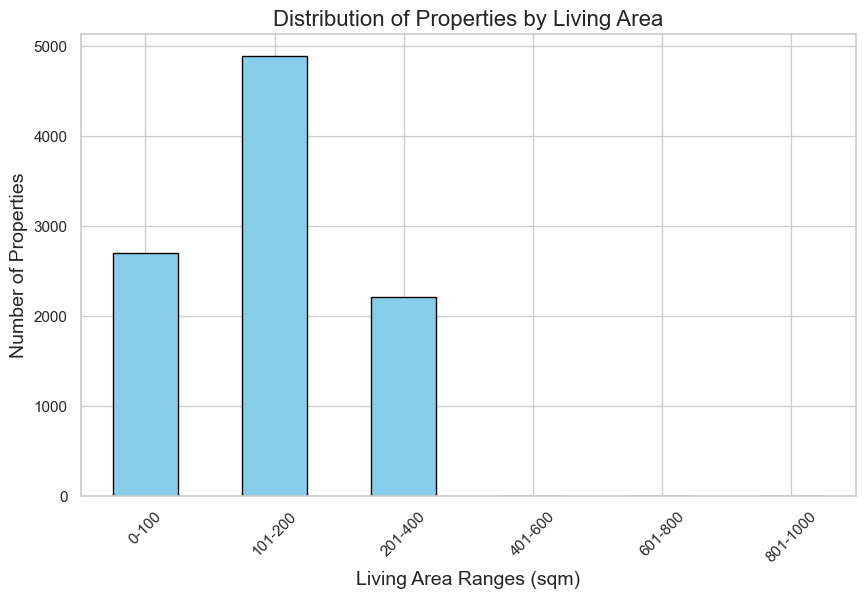

In [1024]:
bins = [0, 100, 200, 400, 600, 800, 1000]  # Define bin edges
bin_labels = ['0-100', '101-200', '201-400', '401-600', '601-800', '801-1000']

# Step 2: Create a new column for the binned data
df['livingAreaBins'] = pd.cut(df['livingArea'], bins=bins, labels=bin_labels, include_lowest=True)

# Step 3: Plot a histogram based on the binned data
plt.figure(figsize=(10, 6))
df['livingAreaBins'].value_counts(sort=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Properties by Living Area', fontsize=16)
plt.xlabel('Living Area Ranges (sqm)', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)
plt.xticks(rotation=45)
plt.show()

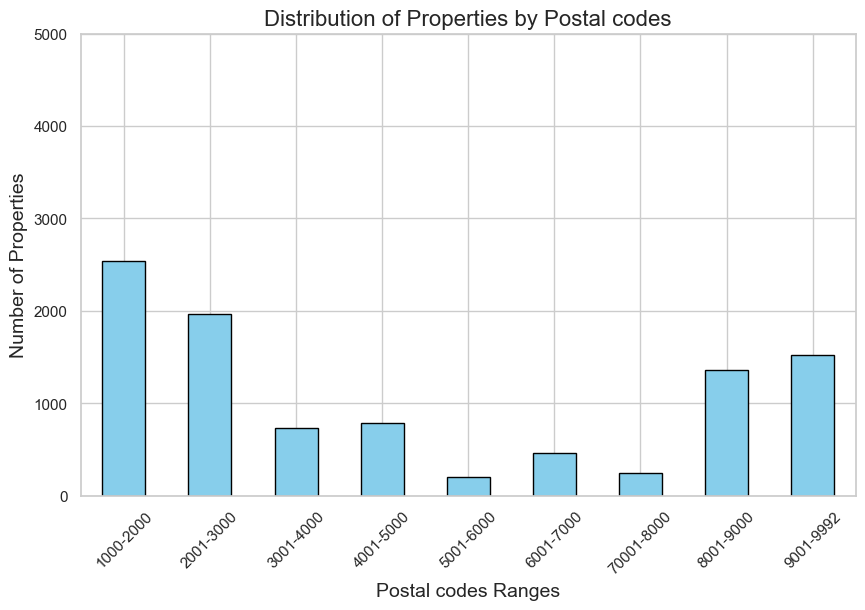

In [1025]:
bins =  [1000, 2000, 3000,4000,5000, 6000, 7000, 8000, 9000,10000]  # Define bin edges
bin_labels = ['1000-2000', '2001-3000', '3001-4000', '4001-5000','5001-6000', '6001-7000', '70001-8000', '8001-9000', '9001-9992']
df['postal_code'] = pd.to_numeric(df['postal_code'], errors='coerce')
# Step 2: Create a new column for the binned data
df['postalBins'] = pd.cut(df['postal_code'], bins=bins, labels=bin_labels, include_lowest=True)
#df['postalBins'] = df['postalBins'].cat.add_categories('Out of Range').fillna('Out of Range')
# Step 3: Plot a histogram based on the binned data
plt.figure(figsize=(10, 6))
df['postalBins'].value_counts(sort=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Properties by Postal codes', fontsize=16)
plt.xlabel('Postal codes Ranges', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0,5000)
plt.show()

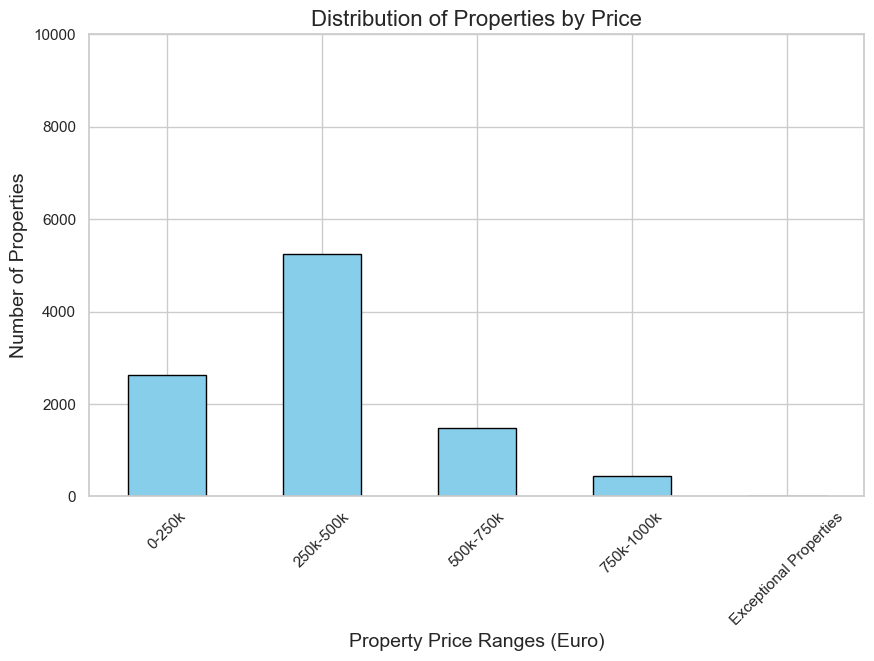

In [1026]:


bins =  [0,250000, 500000, 750000,1000000] 
bin_labels = ['0-250k','250k-500k', '500k-750k', '750k-1000k']
df['price'] = pd.to_numeric(df['price'], errors='coerce')

df['priceBins'] = pd.cut(df['price'], bins=bins, labels=bin_labels, include_lowest=True)
df['priceBins'] = df['priceBins'].cat.add_categories('Exceptional Properties').fillna('Exceptional Properties')

plt.figure(figsize=(10, 6))
df['priceBins'].value_counts(sort=False).plot(kind='bar', color='skyblue', edgecolor='black')
plt.title('Distribution of Properties by Price', fontsize=16)
plt.xlabel('Property Price Ranges (Euro)', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0,10000)
plt.show()


In [1037]:

municipality_data = pd.read_csv('zipcodes_muni_prov.csv', sep='\;')
#municipality_data.info()


/var/folders/db/gqzpbl8d1vxgl2x39wd0j1cw0000gp/T/ipykernel_29636/3050241475.py:1: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  municipality_data = pd.read_csv('zipcodes_muni_prov.csv', sep='\;')


In [1042]:
#municipality_data['Postcode'] = municipality_data['Postcode'].astype(str).str.strip()
municipality_data['Postcode'] = pd.to_numeric(municipality_data['Postcode'], errors='coerce')
municipality_data['Municipality'] = municipality_data['Municipality'].astype(str).str.strip()
municipality_data['Province'] = municipality_data['Province'].astype(str).str.strip()
merged_df= pd.merge(df, municipality_data, left_on='postal_code', right_on='Postcode', how='left')
df=merged_df
df.columns


Index(['house_index', 'bedrooms', 'property_type', 'property_subtype',
       'locality', 'postal_code', 'street', 'number', 'box', 'kitchen',
       'facades', 'price', 'furnished', 'terrace', 'terraceSurface',
       'fireplace', 'fireplaceCount', 'buildingState', 'garden',
       'gardenSurface', 'pool', 'livingArea', 'surfaceOfThePlot', 'typeOfSale',
       'SurfaceBins', 'price_per_sqmt', 'livingAreaBins', 'postalBins',
       'priceBins', 'Postcode_x', 'Locality_x', 'Municipality_x', 'Province_x',
       'Unnamed: 4_x', 'region', 'Postcode_y', 'Locality_y', 'Municipality_y',
       'Province_y', 'Unnamed: 4_y', 'Postcode', 'Locality', 'Municipality',
       'Province', 'Unnamed: 4'],
      dtype='object')

In [1043]:
#Classifing the postal code to regions 'Brussels,Flanders or Wallonia'


# Now you can safely apply the region mapping
def map_region(postal_code):
    if postal_code >= 1000 and postal_code <= 1299:  # Brussels (1000-1200 range)
        return 'Brussels'
    
    elif postal_code >= 2000 and postal_code<= 3999:  # Flanders (2000-9999 range)
        return 'Flanders'
    
    elif postal_code >= 8000 and postal_code <= 8999:  # Wallonia (4000-7999 range)
        return 'Flanders'
    
    
    elif postal_code >= 1300 and postal_code <= 1499:  # Flanders (2000-9999 range)
        return 'Wallonia'
    elif postal_code >= 4000 and postal_code <= 7999:  # Flanders (2000-9999 range)
        return 'Wallonia'
    else:
        return 'Unknown'  # For cases where postal code doesn't match expected ranges

#df['postal_code'] = pd.to_numeric(df['postal_code'], errors='coerce')
df['postal_code']=df['postal_code'].astype('int64')
# Apply the region mapping function
df['region'] = df['postal_code'].apply(map_region)

# Check the value counts of regions
#print(df['region'].value_counts())

In [1044]:

df.groupby('Province')
df = df.dropna(subset=['Province'])  # Remove rows where 'province' is NaN
unique_provinces = df['Province'].unique()
print(unique_provinces)

['Vlaams Brabant' 'Antwerpen' 'Luxemburg' 'Luik' 'Brussel'
 'Oost-Vlaanderen' 'West Vlaanderen' 'Waals Brabant' 'Limburg'
 'Henegouwen' 'Namen']


In [1045]:
df['Province'].isna().sum()

np.int64(0)

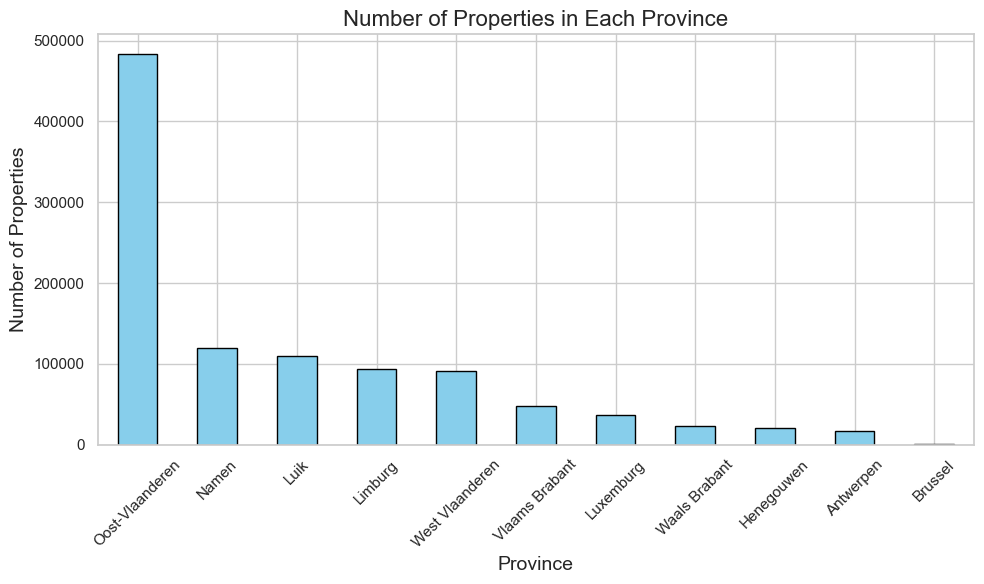

In [1046]:
#Number of properties in each province.
province_counts = df['Province'].value_counts()


plt.figure(figsize=(10, 6))
province_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Step 3: Add titles and labels
plt.title('Number of Properties in Each Province', fontsize=16)
plt.xlabel('Province', fontsize=14)
plt.ylabel('Number of Properties', fontsize=14)
plt.xticks(rotation=45)  # Rotate province names for readability

# Step 4: Show the plot
plt.tight_layout()  # Adjust layout to prevent cutoff
plt.show()

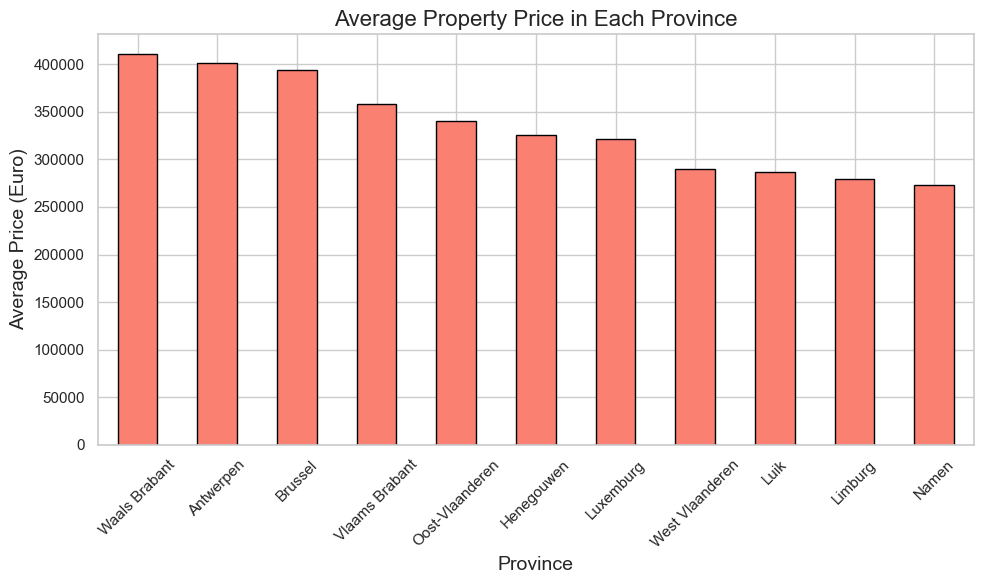

In [1048]:


# Step 1: Group by 'province' and find the maximum price
province_max_price = df.groupby('Province')['price'].agg('mean')

# Step 2: Plot the data
plt.figure(figsize=(10, 6))
province_max_price.sort_values(ascending=False).plot(kind='bar', color='salmon', edgecolor='black')

# Step 3: Add titles and labels
plt.title('Average Property Price in Each Province', fontsize=16)
plt.xlabel('Province', fontsize=14)
plt.ylabel('Average Price (Euro)', fontsize=14)
plt.xticks(rotation=45)  # Rotate province names for readability

# Step 4: Show the plot
plt.tight_layout()  # Adjust layout to prevent cutoff
plt.show()


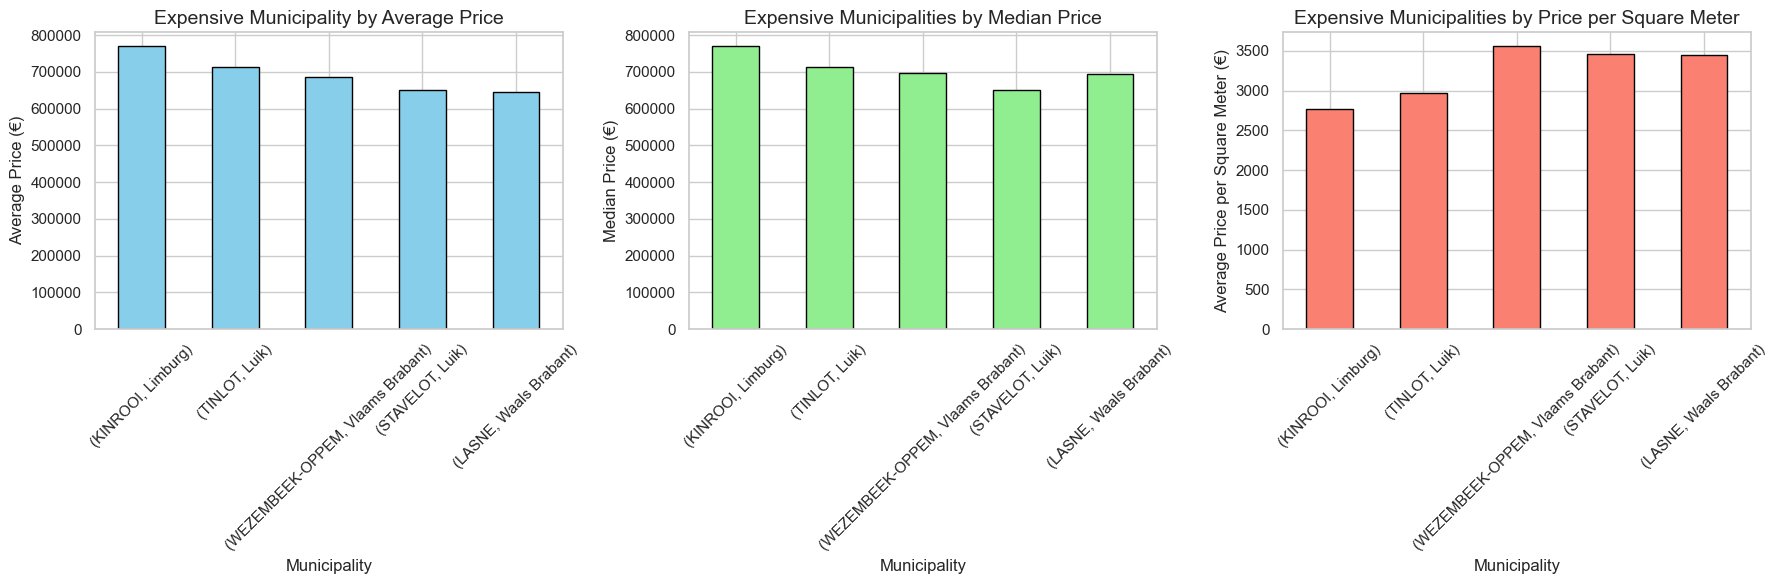

In [1049]:
#What are the most expensive municipalities in Belgium? (Average price, median price, price per square meter)

# Group by Municipality and calculate average price, median price, and average price per square meter
municipality_stats = df.groupby(['Municipality','Province']).agg(
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_price_per_sqmt=('price_per_sqmt', 'mean')
)

# Step 2: Sort municipalities by average price, median price, or price per square meter (top 5)
most_expensive_municipalities = municipality_stats.sort_values('avg_price', ascending=False).head(5)

# Step 3: Plot the data
# Create subplots for the three metrics (Average Price, Median Price, Price per square meter)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Average Price
most_expensive_municipalities['avg_price'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Expensive Municipality by Average Price', fontsize=14)
axes[0].set_xlabel('Municipality', fontsize=12)
axes[0].set_ylabel('Average Price (€)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot Median Price
most_expensive_municipalities['median_price'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Expensive Municipalities by Median Price', fontsize=14)
axes[1].set_xlabel('Municipality', fontsize=12)
axes[1].set_ylabel('Median Price (€)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Plot Average Price per Square Meter
most_expensive_municipalities['avg_price_per_sqmt'].plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Expensive Municipalities by Price per Square Meter', fontsize=14)
axes[2].set_xlabel('Municipality', fontsize=12)
axes[2].set_ylabel('Average Price per Square Meter (€)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

# Adjust the layout
plt.tight_layout()
plt.show()


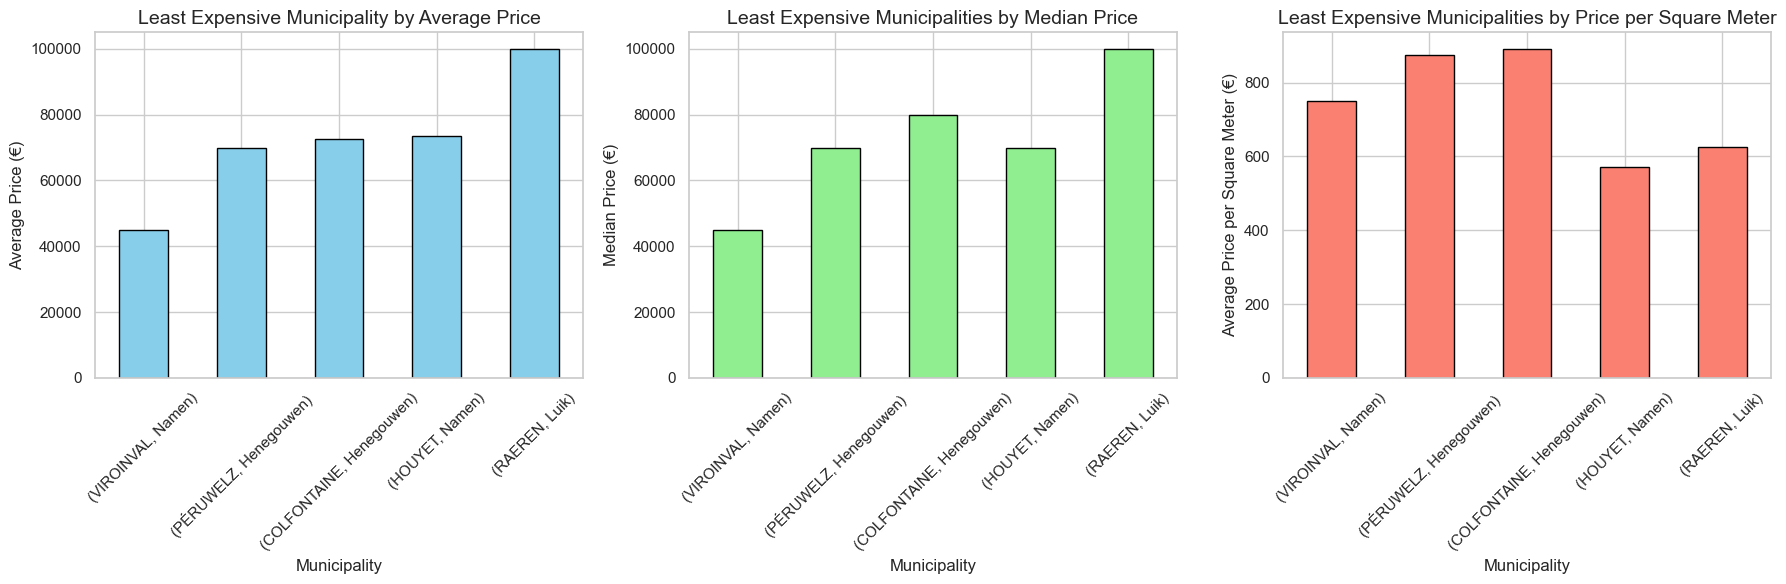

In [1050]:
#What are the less expensive municipalities in Belgium? (Average price, median price, price per square meter)

# Group by Municipality and calculate average price, median price, and average price per square meter
municipality_stats = df.groupby(['Municipality','Province']).agg(
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_price_per_sqmt=('price_per_sqmt', 'mean')
)

# Step 2: Sort municipalities by average price, median price, or price per square meter (top 5)
least_expensive_municipalities = municipality_stats.sort_values('avg_price', ascending=True).head(5)

# Step 3: Plot the data
# Create subplots for the three metrics (Average Price, Median Price, Price per square meter)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Average Price
least_expensive_municipalities['avg_price'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Least Expensive Municipality by Average Price', fontsize=14)
axes[0].set_xlabel('Municipality', fontsize=12)
axes[0].set_ylabel('Average Price (€)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot Median Price
least_expensive_municipalities['median_price'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Least Expensive Municipalities by Median Price', fontsize=14)
axes[1].set_xlabel('Municipality', fontsize=12)
axes[1].set_ylabel('Median Price (€)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Plot Average Price per Square Meter
least_expensive_municipalities['avg_price_per_sqmt'].plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Least Expensive Municipalities by Price per Square Meter', fontsize=14)
axes[2].set_xlabel('Municipality', fontsize=12)
axes[2].set_ylabel('Average Price per Square Meter (€)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

# Adjust the layout
plt.tight_layout()
plt.show()

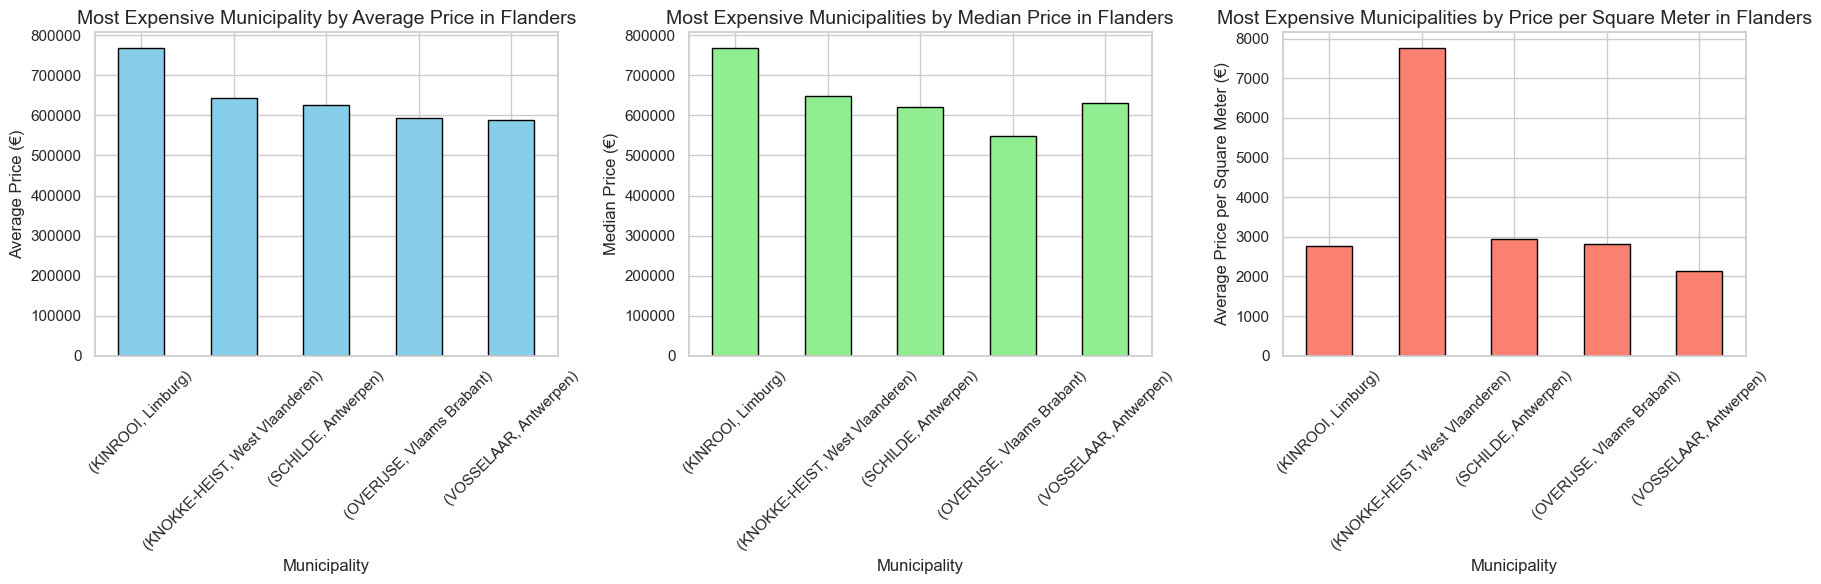

In [1051]:
#What are the most expensive municipalities in Flanders? (Average price, median price, price per square meter)
df_flanders=df[df['region']=='Flanders']
# Group by Municipality and calculate average price, median price, and average price per square meter
municipality_stats = df_flanders.groupby(['Municipality','Province']).agg(
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_price_per_sqmt=('price_per_sqmt', 'mean')
)

# Step 2: Sort municipalities by average price, median price, or price per square meter (top 5)
most_expensive_municipalities = municipality_stats.sort_values('avg_price', ascending=False).head(5)

# Step 3: Plot the data
# Create subplots for the three metrics (Average Price, Median Price, Price per square meter)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Average Price
most_expensive_municipalities['avg_price'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Most Expensive Municipality by Average Price in Flanders', fontsize=14)
axes[0].set_xlabel('Municipality', fontsize=12)
axes[0].set_ylabel('Average Price (€)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot Median Price
most_expensive_municipalities['median_price'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Most Expensive Municipalities by Median Price in Flanders', fontsize=14)
axes[1].set_xlabel('Municipality', fontsize=12)
axes[1].set_ylabel('Median Price (€)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Plot Average Price per Square Meter
most_expensive_municipalities['avg_price_per_sqmt'].plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Most Expensive Municipalities by Price per Square Meter in Flanders', fontsize=14)
axes[2].set_xlabel('Municipality', fontsize=12)
axes[2].set_ylabel('Average Price per Square Meter (€)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

# Adjust the layout
plt.tight_layout()
plt.show()

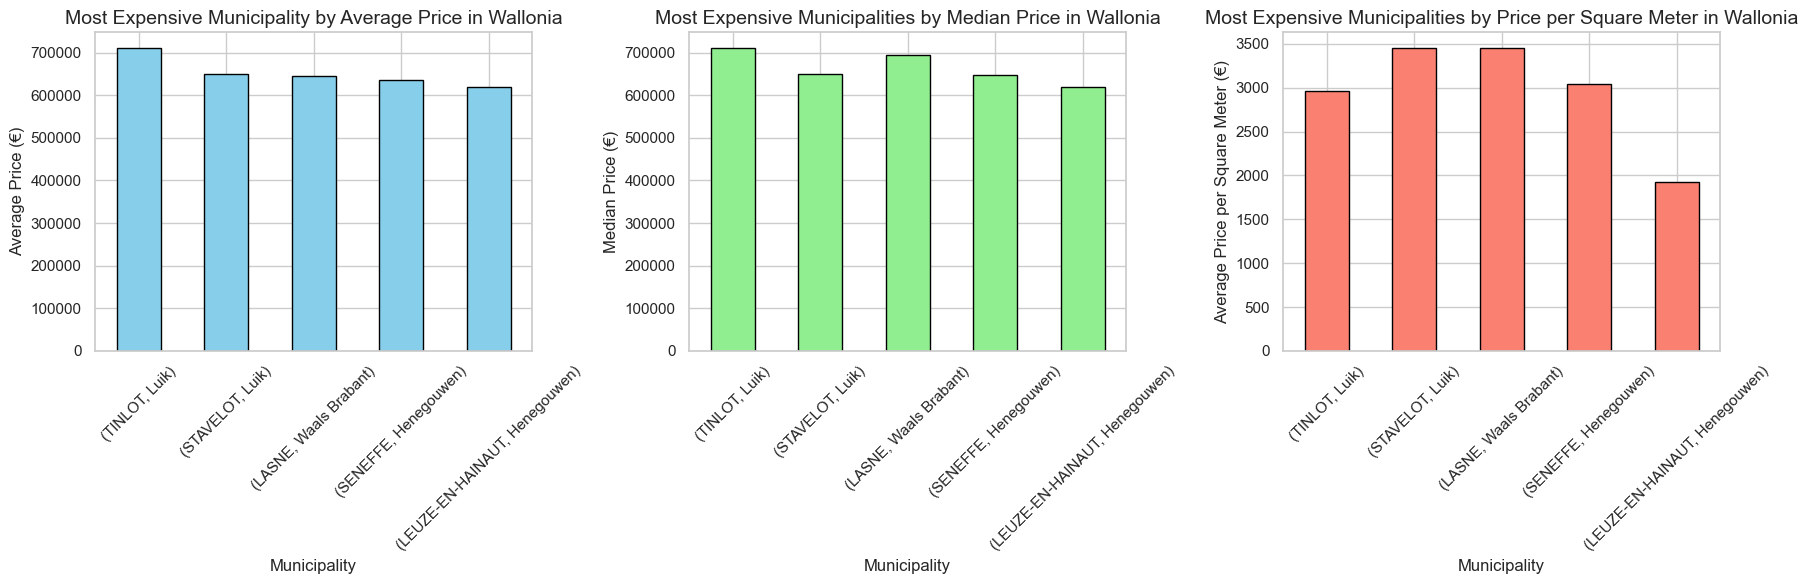

In [1052]:
#What are the most expensive municipalities in Wallonia? (Average price, median price, price per square meter)
#df_wallonia=df[df['region']=='Wallonia']
#What are the most expensive municipalities in Flanders? (Average price, median price, price per square meter)
df_wallonia=df[df['region']=='Wallonia']
# Group by Municipality and calculate average price, median price, and average price per square meter
municipality_stats = df_wallonia.groupby(['Municipality','Province']).agg(
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_price_per_sqmt=('price_per_sqmt', 'mean')
)

# Step 2: Sort municipalities by average price, median price, or price per square meter (top 5)
most_expensive_municipalities = municipality_stats.sort_values('avg_price', ascending=False).head(5)

# Step 3: Plot the data
# Create subplots for the three metrics (Average Price, Median Price, Price per square meter)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Average Price
most_expensive_municipalities['avg_price'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Most Expensive Municipality by Average Price in Wallonia', fontsize=14)
axes[0].set_xlabel('Municipality', fontsize=12)
axes[0].set_ylabel('Average Price (€)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot Median Price
most_expensive_municipalities['median_price'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Most Expensive Municipalities by Median Price in Wallonia', fontsize=14)
axes[1].set_xlabel('Municipality', fontsize=12)
axes[1].set_ylabel('Median Price (€)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Plot Average Price per Square Meter
most_expensive_municipalities['avg_price_per_sqmt'].plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Most Expensive Municipalities by Price per Square Meter in Wallonia', fontsize=14)
axes[2].set_xlabel('Municipality', fontsize=12)
axes[2].set_ylabel('Average Price per Square Meter (€)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

# Adjust the layout
plt.tight_layout()
plt.show()

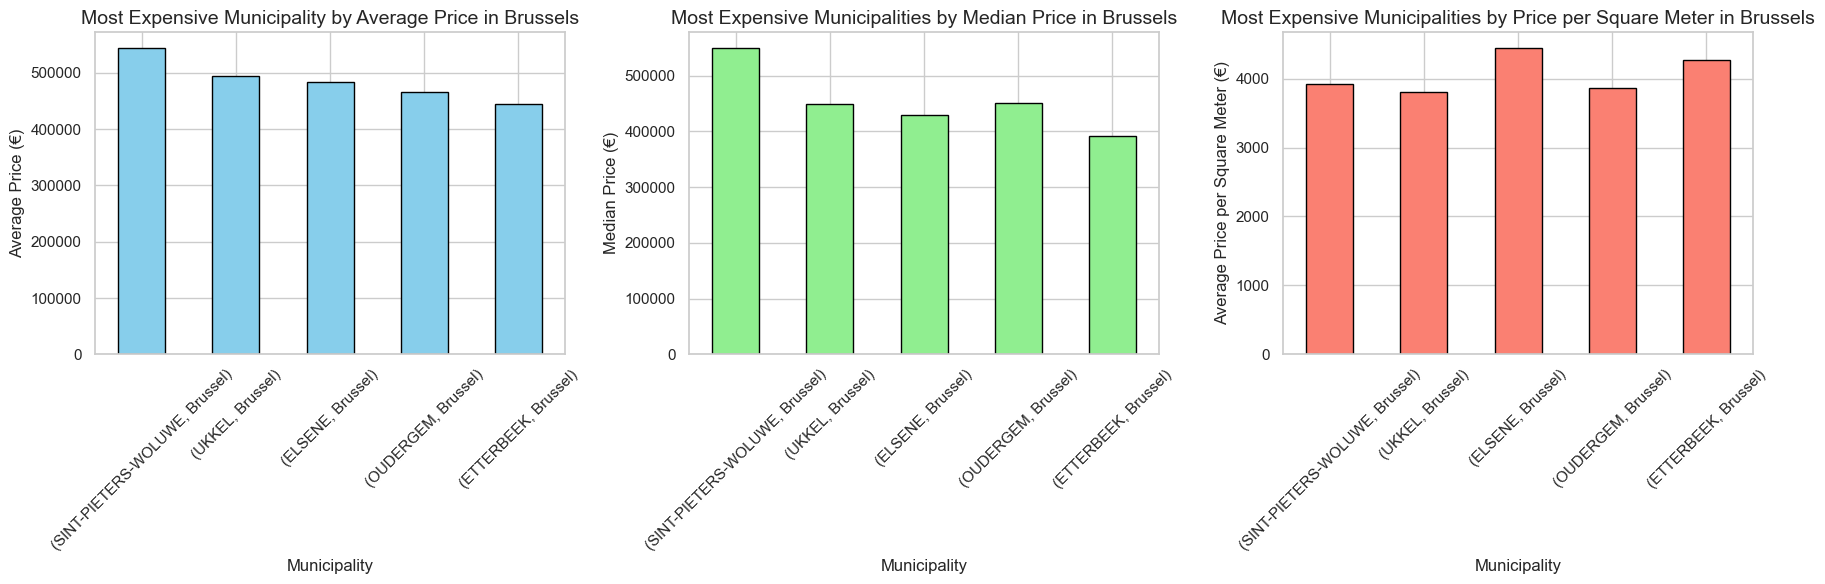

In [1053]:
#What are the most expensive municipalities in Brussels? (Average price, median price, price per square meter)
df_brussel=df[df['region']=='Brussels']
# Group by Municipality and calculate average price, median price, and average price per square meter
municipality_stats = df_brussel.groupby(['Municipality','Province']).agg(
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_price_per_sqmt=('price_per_sqmt', 'mean')
)

# Step 2: Sort municipalities by average price, median price, or price per square meter (top 5)
most_expensive_municipalities = municipality_stats.sort_values('avg_price', ascending=False).head(5)

# Step 3: Plot the data
# Create subplots for the three metrics (Average Price, Median Price, Price per square meter)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Average Price
most_expensive_municipalities['avg_price'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Most Expensive Municipality by Average Price in Brussels', fontsize=14)
axes[0].set_xlabel('Municipality', fontsize=12)
axes[0].set_ylabel('Average Price (€)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot Median Price
most_expensive_municipalities['median_price'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Most Expensive Municipalities by Median Price in Brussels', fontsize=14)
axes[1].set_xlabel('Municipality', fontsize=12)
axes[1].set_ylabel('Median Price (€)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Plot Average Price per Square Meter
most_expensive_municipalities['avg_price_per_sqmt'].plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Most Expensive Municipalities by Price per Square Meter in Brussels', fontsize=14)
axes[2].set_xlabel('Municipality', fontsize=12)
axes[2].set_ylabel('Average Price per Square Meter (€)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

# Adjust the layout
plt.tight_layout()
plt.show()

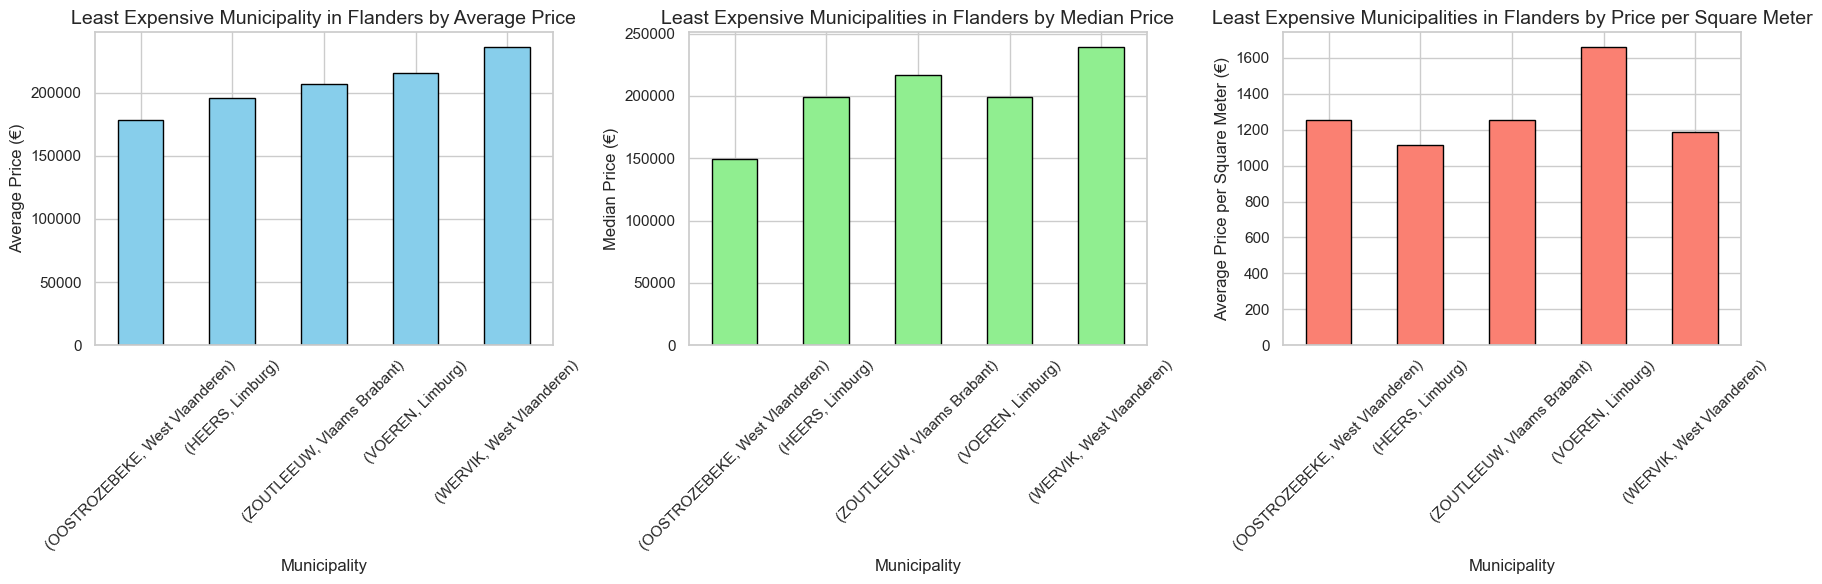

In [1058]:
#What are the less expensive municipalities in Flanders? (Average price, median price, price per square meter)
df_flanders=df[df['region']=='Flanders']
# Group by Municipality and calculate average price, median price, and average price per square meter
municipality_stats = df_flanders.groupby(['Municipality','Province']).agg(
    avg_price=('price', 'mean'),
    median_price=('price', 'median'),
    avg_price_per_sqmt=('price_per_sqmt', 'mean')
)

# Step 2: Sort municipalities by average price, median price, or price per square meter (top 5)
least_expensive_municipalities = municipality_stats.sort_values('avg_price', ascending=True).head(5)

# Step 3: Plot the data
# Create subplots for the three metrics (Average Price, Median Price, Price per square meter)
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot Average Price
least_expensive_municipalities['avg_price'].plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Least Expensive Municipality in Flanders by Average Price', fontsize=14)
axes[0].set_xlabel('Municipality', fontsize=12)
axes[0].set_ylabel('Average Price (€)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)

# Plot Median Price
least_expensive_municipalities['median_price'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Least Expensive Municipalities in Flanders by Median Price', fontsize=14)
axes[1].set_xlabel('Municipality', fontsize=12)
axes[1].set_ylabel('Median Price (€)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

# Plot Average Price per Square Meter
least_expensive_municipalities['avg_price_per_sqmt'].plot(kind='bar', ax=axes[2], color='salmon', edgecolor='black')
axes[2].set_title('Least Expensive Municipalities in Flanders by Price per Square Meter', fontsize=14)
axes[2].set_xlabel('Municipality', fontsize=12)
axes[2].set_ylabel('Average Price per Square Meter (€)', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

# Adjust the layout
plt.tight_layout()
plt.show()

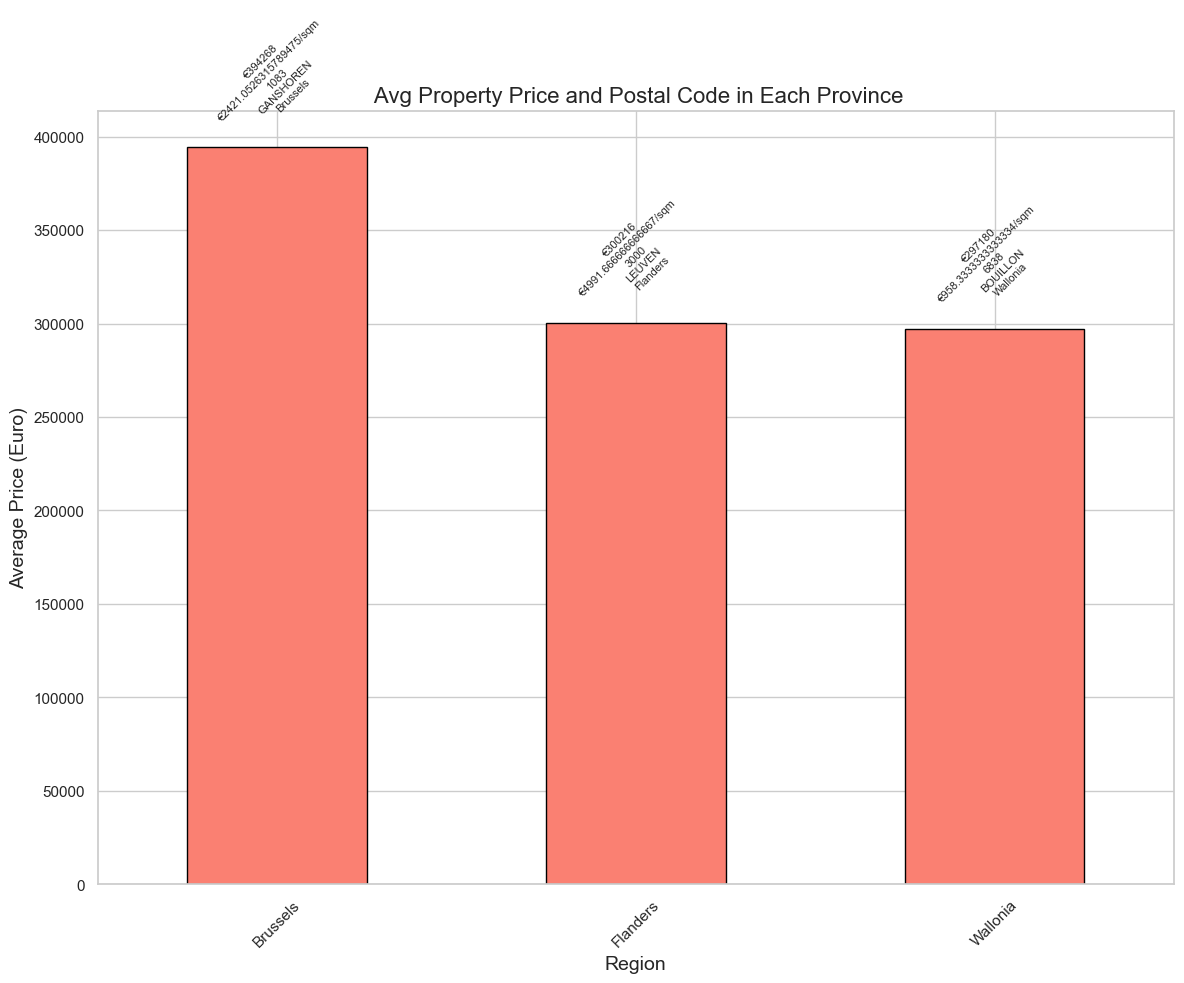

In [1060]:
df_filtered = df[df['region'] != 'Unknown']
# Step 2: Compute the average price by region (province)
avg_prices = df_filtered.groupby('region').agg(
    avg_price=('price', 'mean'),
    postal_code=('postal_code', 'first'),  # assuming the first postal code in the group is representative
    Municipality=('Municipality', 'first'),
    price_per_sqmt=('price_per_sqmt', 'first')  # assuming the first municipality in the group is representative
).reset_index()
avg_prices.columns
# Step 3: Set the Region as the index for plotting
avg_prices.set_index('region', inplace=True)

# Step 3: Plot the data
plt.figure(figsize=(12, 10))
avg_prices['avg_price'].sort_values(ascending=False).plot(kind='bar', color='salmon', edgecolor='black')

# Step 4: Annotate the highest price and postal code on the bars

for index, (region, row) in enumerate(avg_prices.sort_values('avg_price', ascending=False).iterrows()):
    postcode = row['postal_code']
    municipality = row['Municipality']
    reg=region
    price = row['avg_price']
    price_per_sqm=row['price_per_sqmt']
    
    # Format the annotation text
    annotation = f'€{price:.0f}\n€{price_per_sqm}/sqm\n{postcode}\n{municipality}\n{reg}'

    plt.text(index,price, annotation , ha='center', va='bottom', fontsize=8, rotation=45)

# Step 5: Add titles and labels
plt.title(' Avg Property Price and Postal Code in Each Province', fontsize=16)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Average Price (Euro)', fontsize=14)
plt.xticks(rotation=45)  # Rotate province names for readability

# Step 6: Show the plot
plt.tight_layout()
plt.show()


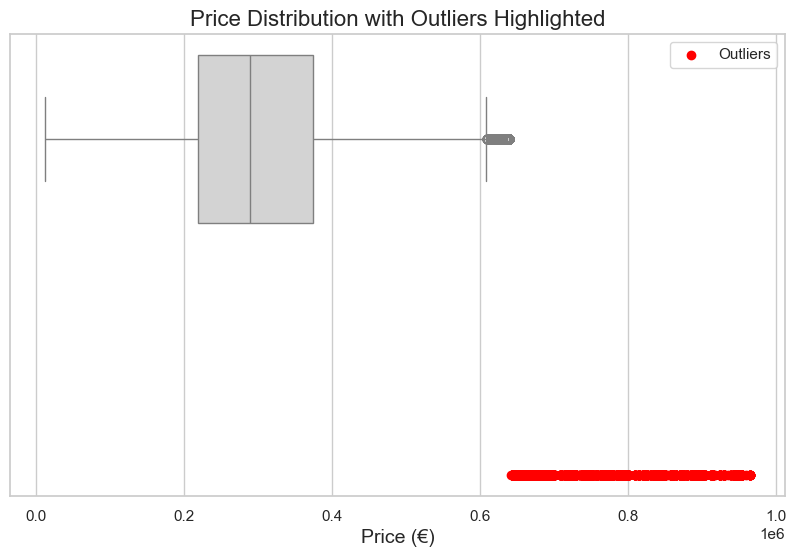

In [1062]:

#Plot the outliers
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate IQR for 'price' column
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Separate outliers and non-outliers
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
non_outliers = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]

# Plot non-outliers and outliers separately on the boxplot
plt.figure(figsize=(10, 6))

# Plot normal data
sns.boxplot(x=non_outliers['price'], color='lightgray', width=0.5)

# Plot outliers as red points
plt.scatter(outliers['price'], [1]*len(outliers), color='red', label='Outliers', zorder=5)

# Title and labels
plt.title('Price Distribution with Outliers Highlighted', fontsize=16)
plt.xlabel('Price (€)', fontsize=14)
plt.legend()
plt.show()
